In [326]:
# libraries
import pandas as pd
import numpy as np
import cv2 as cv
import torch
import torch.nn as nn
import torch.optim as optim

In [327]:
import os 

def im_to_array(path, size=(128,128)):
    im_list = []
    for filename in os.listdir(path):
        if filename.endswith('.jpg'):
            im = cv.imread(os.path.join(path, filename), cv.IMREAD_GRAYSCALE)
            im = cv.resize(im, size)  
            im = im/ 255.0                       
            im_list.append(im.flatten())
            
    return np.array(im_list).reshape(len(im_list), -1)

In [328]:
# using cv reading an image
im_test_dog = cv.imread("D:\\ITC\\Year3\\I3 s2\\Introduction_Machinlearning\\Project\\project4\\animal\\Test\\Dog\\dog (1).jpg", cv.IMREAD_GRAYSCALE)
print(im_test_dog.shape)

im_test_cat = cv.imread("D:\\ITC\\Year3\\I3 s2\\Introduction_Machinlearning\\Project\\project4\\animal\\Test\\Cat\\cat (11).jpg", cv.IMREAD_GRAYSCALE)
print(im_test_cat.shape)

(1280, 960)
(1104, 828)


In [329]:
im_train_dog = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\animal\Train\dog")
y_train_dog = np.ones(im_train_dog.shape[0])

im_train_cat = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\animal\Train\cat")
y_train_cat = np.zeros(im_train_cat.shape[0])

X_train = np.concatenate((im_train_dog, im_train_cat), axis=0)
y_train = np.concatenate((y_train_dog, y_train_cat), axis=0)


print(X_train.shape)
print(y_train.shape)




(160, 16384)
(160,)


In [330]:
im_test_dog = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\animal\Test\Dog")
y_test_dog = np.ones(im_test_dog.shape[0])

im_test_cat = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\animal\Test\Cat")
y_test_cat = np.zeros(im_test_cat.shape[0])

X_test = np.concatenate((im_test_dog, im_test_cat), axis=0)
y_test = np.concatenate((y_test_dog, y_test_cat), axis=0)

print(X_test.shape)
print(y_test.shape)

(20, 16384)
(20,)


In [331]:
im_val_dog = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\animal\Validation\Dog")
y_val_dog = np.ones(im_val_dog.shape[0])

im_val_cat = im_to_array(r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\animal\Validation\Cat")
y_val_cat = np.zeros(im_val_cat.shape[0])

X_val = np.concatenate((im_val_dog, im_val_cat), axis=0)
y_val = np.concatenate((y_val_dog, y_val_cat), axis=0)

print(X_val.shape)
print(y_val.shape)

(20, 16384)
(20,)


In [332]:
np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)
np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)
np.save("X_val.npy", X_val)
np.save("y_val.npy", y_val)

In [333]:

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([160, 16384])
torch.Size([160])


In [334]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(X_test_tensor.shape)
print(y_test_tensor.shape)

torch.Size([20, 16384])
torch.Size([20])


In [335]:
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

print(X_val_tensor.shape)
print(y_val_tensor.shape)

torch.Size([20, 16384])
torch.Size([20])


In [336]:
# # define model
def my_ANN (X, w1,b1,w2,b2,w3,b3):
#     # layer 1
     Z1 = torch.matmul(X,w1) + b1
     A1 = torch.relu(Z1)
#     # layer 2
     Z2 = torch.matmul(A1,w2 ) + b2
     A2 = torch.relu(Z2)
#     # layer 3
     Z3 = torch.matmul(A2,w3) + b3
     return Z3

In [337]:
from torch.utils.data import TensorDataset, DataLoader
# Training

b1 = torch.randn(1, 128, requires_grad=True)
b2 = torch.randn(1, 64, requires_grad=True)
b3 = torch.randn(1, 2, requires_grad=True)

W1 = torch.randn(16384, 128) * 0.01
W1.requires_grad_()

W2 = torch.randn(128, 64) * 0.01
W2.requires_grad_()

W3 = torch.randn(64, 2) * 0.01
W3.requires_grad_()




cost_func = nn.CrossEntropyLoss()
optimizer = optim.SGD([W1, b1, W2, b2, W3, b3], lr=0.01)
train_datadet = TensorDataset(X_train_tensor, y_train_tensor)
val_datadet = TensorDataset(X_val_tensor, y_val_tensor)
test_datadet = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_datadet, batch_size=100, shuffle=True)
val_loader = DataLoader(val_datadet, batch_size=100, shuffle=False)

for epoch in range(1,501):
    # ---- Training ----
    model_loss = 0
    for X_batch, y_batch in train_loader:
        Z = my_ANN(X_batch, W1, b1, W2, b2, W3, b3)
        loss = cost_func(Z, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        model_loss += loss.item()
    
    # ---- Validation ----
    correct, total = 0, 0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            Z_val = my_ANN(X_val, W1, b1, W2, b2, W3, b3)
            preds = torch.argmax(Z_val, dim=1)
            correct += (preds == y_val).sum().item()
            total += y_val.size(0)
    val_acc = correct / total

    print(f"Epoch {epoch:03d}, Train Loss={model_loss/len(train_loader):.4f}, Val Acc={val_acc:.4f}")



Epoch 001, Train Loss=0.7100, Val Acc=0.5000
Epoch 002, Train Loss=0.7022, Val Acc=0.5000
Epoch 003, Train Loss=0.7003, Val Acc=0.5000
Epoch 004, Train Loss=0.6954, Val Acc=0.5000
Epoch 005, Train Loss=0.6950, Val Acc=0.5000
Epoch 006, Train Loss=0.6939, Val Acc=0.5000
Epoch 007, Train Loss=0.6943, Val Acc=0.5000
Epoch 008, Train Loss=0.6941, Val Acc=0.5000
Epoch 009, Train Loss=0.6932, Val Acc=0.5000
Epoch 010, Train Loss=0.6937, Val Acc=0.5000
Epoch 011, Train Loss=0.6930, Val Acc=0.5000
Epoch 012, Train Loss=0.6936, Val Acc=0.5000
Epoch 013, Train Loss=0.6931, Val Acc=0.5000
Epoch 014, Train Loss=0.6930, Val Acc=0.5000
Epoch 015, Train Loss=0.6934, Val Acc=0.5000
Epoch 016, Train Loss=0.6930, Val Acc=0.5000
Epoch 017, Train Loss=0.6929, Val Acc=0.5000
Epoch 018, Train Loss=0.6927, Val Acc=0.5000
Epoch 019, Train Loss=0.6954, Val Acc=0.5000
Epoch 020, Train Loss=0.6932, Val Acc=0.5000
Epoch 021, Train Loss=0.6931, Val Acc=0.5000
Epoch 022, Train Loss=0.6929, Val Acc=0.5000
Epoch 023,

In [338]:
# Evaluate
Z= my_ANN(X_train_tensor, W1, b1, W2, b2, W3, b3)
y_pred = torch.argmax(Z,dim=1)
acc = torch.mean((y_pred == y_train_tensor).float())
print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 94.38%


In [339]:
Z_test = my_ANN(X_test_tensor, W1, b1, W2, b2, W3, b3)
y_pred_test = torch.argmax(Z_test, dim=1)
acc_test = torch.mean((y_pred_test == y_test_tensor).float())
print(f"Accuracy: {acc_test*100:.2f}%")


Accuracy: 70.00%


In [340]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Collect predictions and true labels
y_true = []
y_pred = []

with torch.no_grad():
    for X_val, y_val in val_loader:   # val_loader = DataLoader for your validation set
        Z_val = my_ANN(X_val, W1, b1, W2, b2, W3, b3)
        probs = torch.softmax(Z_val, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(y_val.numpy())
        y_pred.extend(preds.numpy())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Cat", "Dog"]))


Confusion Matrix:
 [[4 6]
 [4 6]]

Classification Report:
              precision    recall  f1-score   support

         Cat       0.50      0.40      0.44        10
         Dog       0.50      0.60      0.55        10

    accuracy                           0.50        20
   macro avg       0.50      0.50      0.49        20
weighted avg       0.50      0.50      0.49        20



In [341]:
print(f"Train range: {X_train_tensor.min():.4f} to {X_train_tensor.max():.4f}")
print(f"Test range:  {X_test_tensor.min():.4f} to {X_test_tensor.max():.4f}")
print(f"Val range:   {X_val_tensor.min():.4f} to {X_val_tensor.max():.4f}")

Train range: 0.0000 to 1.0000
Test range:  0.0000 to 1.0000
Val range:   0.0000 to 1.0000


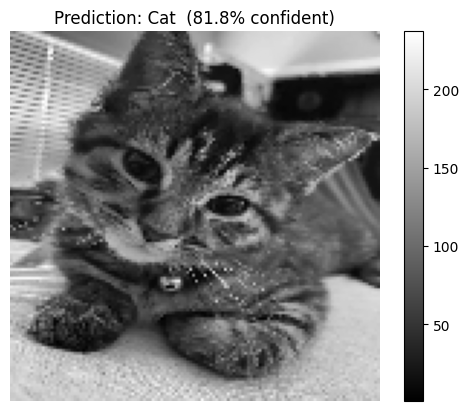

Cat probability: 81.8%
Dog probability: 18.2%


In [395]:
import cv2 as cv
import torch
import matplotlib.pyplot as plt

def predict_one(image_path, size=(128, 128), threshold=0.80, margin=0.15):
    # Load grayscale image
    img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    if img is None:
        print("Could not read the image. Check the path.")
        return
    
    # Preprocess
    img_resized = cv.resize(img, size)                   # must match training size
    x = img_resized.flatten() / 255.0                    # scale to [0,1]
    x_tensor = torch.tensor(x, dtype=torch.float32).reshape(1, -1)

    # Run the model
    with torch.no_grad():
        # Class names (only 2 trained classes)
        class_names = ["Cat", "Dog", "Other"]  # "Other" is for low confidence cases
        Z = my_ANN(x_tensor, W1, b1, W2, b2, W3, b3)     # forward pass
        probs = torch.softmax(Z, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        name = class_names[pred]
        top_conf = probs[0, pred].item()
    

    # Confidence and margin checks
    cat_conf = probs[0, 0].item()
    dog_conf = probs[0, 1].item()
    
    diff = abs(cat_conf - dog_conf)
    threshold = 0.65
    margin = 0.05
    if top_conf < threshold or diff < margin:
        name = "Other"
    else:
        name = class_names[pred]

    confidence = top_conf * 100

    # Show image with prediction
    plt.imshow(img_resized, cmap="gray")
    plt.axis("off")
    plt.title(f"Prediction: {name}  ({confidence:.1f}% confident)")
    plt.colorbar()
    plt.show()
    
    print(f"Cat probability: {cat_conf*100:.1f}%")
    print(f"Dog probability: {dog_conf*100:.1f}%")

    if name == "Other":
        print(f"Rejected: Model not confident enough (< {threshold*100:.0f}%) "
              f"AND Cat/Dog difference too small (< {margin*100:.0f}%).")

    return name
name = predict_one(r'D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\example\52.jpg')

In [343]:
# Save new weights after good training
torch.save({
    "W1": W1.detach(), "b1": b1.detach(),
    "W2": W2.detach(), "b2": b2.detach(),
    "W3": W3.detach(), "b3": b3.detach()
}, r"D:\ITC\Year3\I3 s2\Introduction_Machinlearning\Project\project4\weights.pth")


In [344]:
np.save("W1.npy", W1.detach().numpy())
np.save("b1.npy", b1.detach().numpy())
np.save("W2.npy", W2.detach().numpy())
np.save("b2.npy", b2.detach().numpy())
np.save("W3.npy", W3.detach().numpy())
np.save("b3.npy", b3.detach().numpy())
